# LR with multiple features

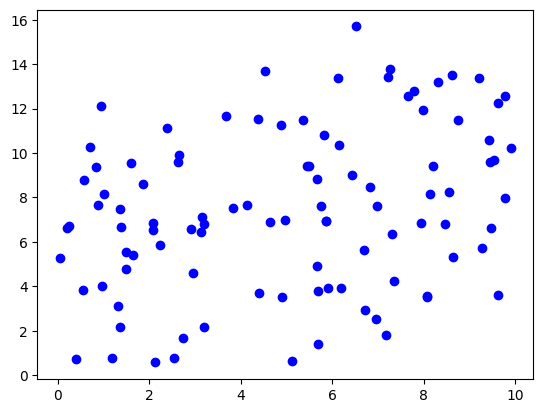

initial predictions:
 [[12.87322504]
 [15.24580876]
 [12.52299195]
 [ 7.90511736]
 [ 6.80890124]]
(100, 1)
initial cost: 36.666780297917704


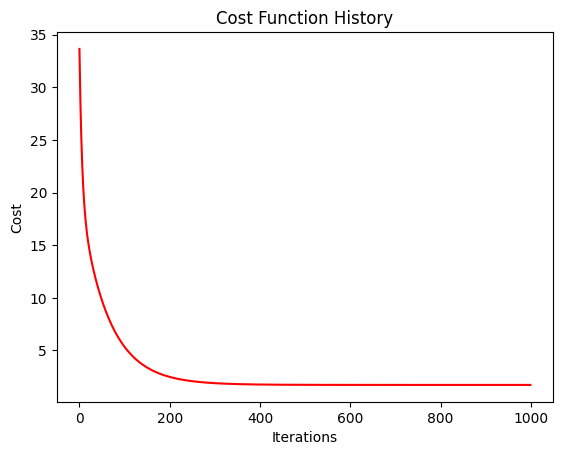

Final parameters (theta):
 [[-0.18199077]
 [ 0.22330207]
 [ 0.20103956]
 [ 1.05526704]]
Final cost: 1.7302641250630066


In [19]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)

n_samples = 100
x = np.random.rand(n_samples, 3) * 10
y = (0.3 * x[:,0] + 0.2 * x[:, 1] + x[:, 2] + np.random.randn(n_samples) * 2).reshape(-1,1)

plt.scatter(x[:, 0], y, color='blue', label='feature 1 VS target')
plt.show()

# add bias term 'ceta note' (column of ones)
x_bias = np.c_[np.ones((n_samples, 1)), x]

# hypothesis function
def hypothesis(x, theta):
    return x.dot(theta)

initial_theta = np.random.randn(x_bias.shape[1], 1)
initial_predictions = hypothesis(x_bias, initial_theta)
print("initial predictions:\n", initial_predictions[:5])
print(initial_predictions.shape)

# Cost function (mean squared error)
def compute_cost(x, y, theta):
    m = len(y)
    predictions = hypothesis(x, theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

initial_cost = compute_cost(x_bias, y, initial_theta)
print("initial cost:", initial_cost)

# Gradient Descent
def gradient_descent(x, y, theta, learning_rate=0.01, iterations=1000):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = hypothesis(x, theta)
        errors = predictions - y
        gradients = (1 / m) * x.T.dot(errors)
        theta -= learning_rate * gradients
        cost_history[i] = compute_cost(x, y, theta)

    return theta, cost_history

learning_rate = 0.001
iterations = 1000
theta_final, cost_history = gradient_descent(x_bias, y, initial_theta, learning_rate, iterations)

# Plot the cost history
plt.plot(range(iterations), cost_history, color='red')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function History')
plt.show()

print("Final parameters (theta):\n", theta_final)
print("Final cost:", compute_cost(x_bias, y, theta_final))


In [16]:
# using sklearn for comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)
print("Sklearn parameters (theta):\n", np.c_[model.intercept_, model.coef_])
print("Sklearn cost (MSE):", mean_squared_error(y, y_pred)/2)

Sklearn parameters (theta):
 [[-0.0995722   0.21826495  0.19599133  1.0506462 ]]
Sklearn cost (MSE): 1.7299108784943191


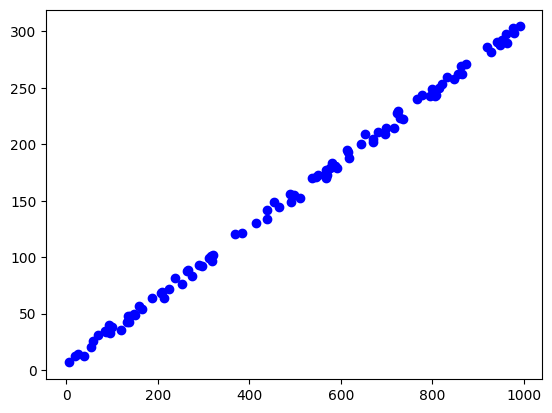

initial predictions:
 [[0.20390051]
 [0.24544582]
 [0.19633741]
 [0.11859438]
 [0.10059038]]
(100, 1)
initial cost: 16171.760291807457


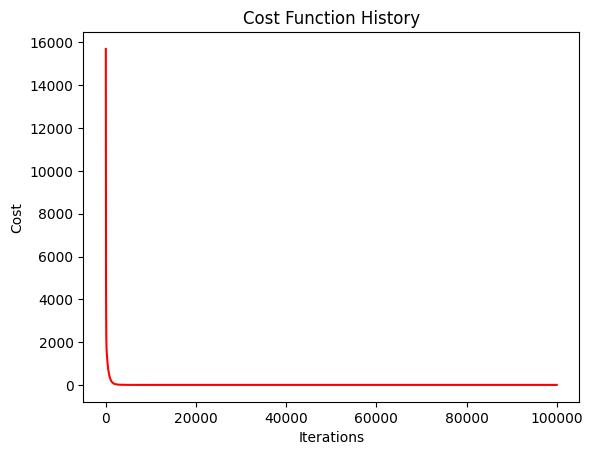

Final parameters (theta):
 [[-9.95721951e-01]
 [ 1.74337616e+03]
 [ 1.11221741e+01]
 [ 6.22666084e+01]]
Final cost: 1.729910878494321


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

np.random.seed(0)

n_samples = 100
x = np.random.rand(n_samples, 3) * 10
# Introduce feature scaling, will bias to feature 1 if not scaled
# Solution to this biased is normalization to make all in range [0,1]
# normalization: x1 = (size - mean) / max
x[:, 0] = x[:, 0] * 100 # scale feature 100
y = (0.3 * x[:,0] + 0.2 * x[:, 1] + x[:, 2] + np.random.randn(n_samples) * 2).reshape(-1,1)

plt.scatter(x[:, 0], y, color='blue', label='feature 1 VS target')
plt.show()

# add bias term 'ceta note' (column of ones)
x_bias = np.c_[np.ones((n_samples, 1)), x]
x = normalize(x_bias, axis=0, copy=False)

# hypothesis function
def hypothesis(x, theta):
    return x.dot(theta)

initial_theta = np.random.randn(x_bias.shape[1], 1)
initial_predictions = hypothesis(x_bias, initial_theta)
print("initial predictions:\n", initial_predictions[:5])
print(initial_predictions.shape)

# Cost function (mean squared error)
def compute_cost(x, y, theta):
    m = len(y)
    predictions = hypothesis(x, theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

initial_cost = compute_cost(x_bias, y, initial_theta)
print("initial cost:", initial_cost)

# Gradient Descent
def gradient_descent(x, y, theta, learning_rate=0.01, iterations=1000):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = hypothesis(x, theta)
        errors = predictions - y
        gradients = (1 / m) * x.T.dot(errors)
        theta -= learning_rate * gradients
        cost_history[i] = compute_cost(x, y, theta)

    return theta, cost_history

learning_rate = 0.5
iterations = 100000
theta_final, cost_history = gradient_descent(x_bias, y, initial_theta, learning_rate, iterations)

# Plot the cost history
plt.plot(range(iterations), cost_history, color='red')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function History')
plt.show()

print("Final parameters (theta):\n", theta_final)
print("Final cost:", compute_cost(x_bias, y, theta_final))


# Polynomial Regression

(100, 3) (100, 1)


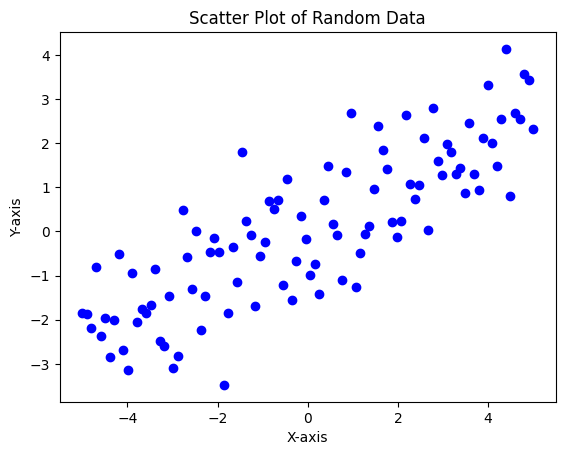

Initial Cost: 60.876604782263776


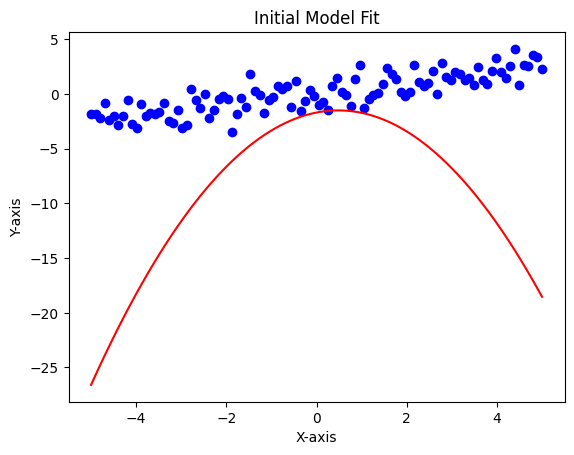

Final Weights: [[-0.07661   ]
 [ 0.49737558]
 [ 0.01547993]]
Final Cost: 0.46887855757864993


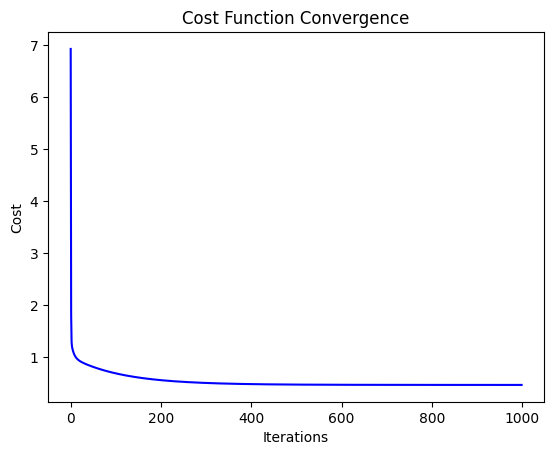

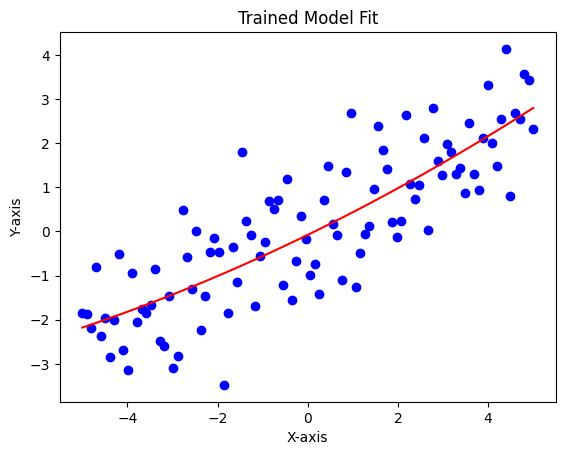

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

x = np.linspace(-5, 5, 100)
y = np.random.randn(100) + 0.5 * x
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
# x_poly = np.concatenate((np.ones((100, 1)), x), axis=1) # Add intercept term to x

print(x_poly.shape, y.shape)

plt.scatter(x, y, color='blue', label='Data Points')
plt.title('Scatter Plot of Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

def hypothesis(theta, x):
    return x.dot(theta)

# Initialize the weights
Theta = np.random.randn(x_poly.shape[1], 1)
# Theta = Theta.reshape(-1, 1)


def cost_function(x, y, theta):
    m = len(y)
    predictions = hypothesis(theta, x)
    cost = (1 / (2 * m) * np.sum(np.square(predictions - y)))
    return cost

initial_cost = cost_function(x_poly, y, Theta)
print(f'Initial Cost: {initial_cost}')


# Initial model visualization
initial_predictions = hypothesis(Theta, x_poly)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, initial_predictions, color='red', label='Initial Model')
plt.title('Initial Model Fit')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

# Gradient Descent
def gradient_descent(x, y, theta, learning_rate=0.0001, iterations=100):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = hypothesis(theta, x)
        errors = predictions - y
        gradient = (x.T.dot(errors)) / m
        theta -= learning_rate * gradient
        cost_history[i] = cost_function(x, y, theta)

    return theta, cost_history
    
learning_rate = 0.01
iterations = 1000
Theta_final, cost_history = gradient_descent(x_poly, y, Theta, learning_rate, iterations)
print(f'Final Weights: {Theta_final}')
final_cost = cost_function(x_poly, y, Theta_final)
print(f'Final Cost: {final_cost}')

# cost history visualization
plt.plot(range(iterations), cost_history, color='blue')
plt.title('Cost Function Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

# Trained model visualization
final_predictions = hypothesis(Theta_final, x_poly)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, final_predictions, color='red', label='Trained Model')
plt.title('Trained Model Fit')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()
